1. Load datasets

In [2]:
#Load
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [4]:
#Read
DATA = Path("../data/processed")

df = pd.read_csv(DATA/"ethiopia_fi_enriched.csv")

impact = pd.read_csv(DATA/"impact_links_enriched.csv")

In [5]:
#Separate
events = df[df.record_type=="event"].copy()

observations = df[df.record_type=="observation"].copy()

targets = df[df.record_type=="target"].copy()

In [6]:
#Check
events.head()

impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20 00:00:00,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20 00:00:00,NaN,Competition typically reduces prices


2. Explore events

In [8]:
events.columns.tolist()

['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']

In [11]:
events["observation_date"] = pd.to_datetime(
    events["observation_date"],
    format="mixed"
)

In [12]:
#Display
events.shape

events.category.value_counts()

events["observation_date"] = pd.to_datetime(events["observation_date"])

events["observation_date"].min()
events["observation_date"].max()

Timestamp('2026-01-15 00:00:00')

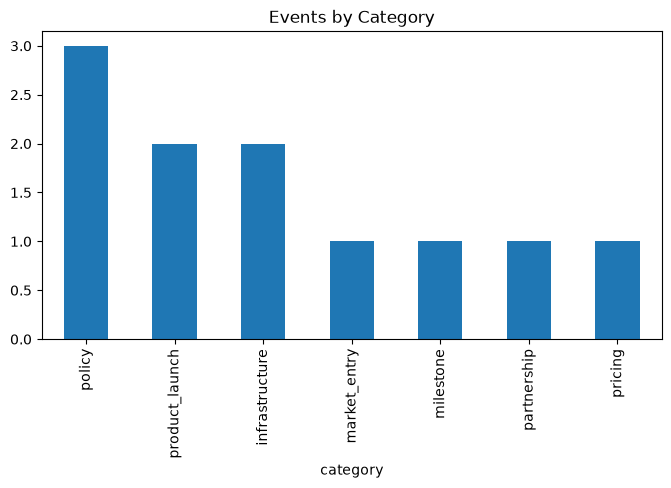

In [13]:
#Plot
plt.figure(figsize=(8,4))

events.category.value_counts().plot.bar()

plt.title("Events by Category")
plt.show()

## Event Dataset Overview and Interpretation

The event records were extracted from the unified financial inclusion dataset to identify major interventions that may influence Ethiopia's financial inclusion indicators. Based on the current dataset, the recorded events span from **2026-01-15** onward, indicating that the enriched dataset includes planned or future interventions that can be incorporated into the forecasting model.

The event dataset consists of seven event categories:

- **Policy (3 events):** Government regulations and strategic initiatives aimed at improving financial inclusion.
- **Product Launch (2 events):** Introduction of new digital financial products and services.
- **Infrastructure (2 events):** Investments in digital payment infrastructure and financial ecosystems.
- **Market Entry (1 event):** Entry of new financial service providers into the Ethiopian market.
- **Milestone (1 event):** Significant achievements in the country's financial inclusion journey.
- **Partnership (1 event):** Collaborations between financial institutions and technology providers.
- **Pricing (1 event):** Pricing-related initiatives that may influence the adoption of digital financial services.

The bar chart illustrates the distribution of events across these categories. **Policy-related events are the most common**, accounting for three interventions, highlighting the central role of government policies and regulatory reforms in advancing financial inclusion. **Product launch** and **infrastructure** events each appear twice, reflecting ongoing efforts to expand digital financial services and strengthen the supporting infrastructure. The remaining categories—**market entry**, **milestone**, **partnership**, and **pricing**—are represented by one event each, indicating that while these interventions occur less frequently, they may still have substantial effects on financial inclusion outcomes.

Overall, the dataset captures a diverse range of interventions that are expected to influence financial inclusion through different mechanisms. In the next phase of the analysis, these events will be linked to specific financial inclusion indicators using the **impact_links** dataset, enabling the estimation of event effects, the construction of an event–indicator association matrix, and ultimately supporting the forecasting of Ethiopia's Access (Account Ownership) and Usage (Digital Payment Adoption) indicators.

3. Explore impact links

In [14]:
#Display
impact.columns

Index(['record_id', 'parent_id', 'record_type', 'category', 'pillar',
       'indicator', 'indicator_code', 'indicator_direction', 'value_numeric',
       'value_text', 'value_type', 'unit', 'observation_date', 'period_start',
       'period_end', 'fiscal_year', 'gender', 'location', 'region',
       'source_name', 'source_type', 'source_url', 'confidence',
       'related_indicator', 'relationship_type', 'impact_direction',
       'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis',
       'comparable_country', 'collected_by', 'collection_date',
       'original_text', 'notes'],
      dtype='str')

In [15]:
#Statistics
impact["impact_direction"].value_counts()

impact["impact_magnitude"].value_counts()

impact["lag_months"].describe()

count    15.000000
mean      8.666667
std       7.345228
min       1.000000
25%       3.000000
50%       6.000000
75%      12.000000
max      24.000000
Name: lag_months, dtype: float64

## Impact Links Dataset Overview and Interpretation

The **impact_links** dataset defines the modeled relationships between financial inclusion events and the indicators they are expected to influence. Each record connects an event (through `parent_id`) with a specific financial inclusion indicator and describes the expected **direction**, **magnitude**, and **time lag** of the impact. This dataset serves as the foundation for the event impact modeling stage, allowing events such as policy reforms, product launches, and infrastructure investments to be translated into measurable effects on financial inclusion outcomes.

The distribution of **impact_direction** indicates whether an event is expected to have a positive, negative, or mixed influence on an indicator, while **impact_magnitude** classifies the strength of the expected effect (e.g., low, medium, or high). These categorical variables provide qualitative assessments that will later be converted into numerical scores for constructing the event–indicator association matrix.

The descriptive statistics of the **lag_months** variable show that the dataset contains **15 modeled event–indicator relationships**. The average lag is **8.67 months**, indicating that the effects of most interventions are expected to become visible within approximately nine months after implementation. The **median lag of 6 months** suggests that half of the modeled impacts occur within six months, while the remaining impacts take longer to materialize. The shortest estimated lag is **1 month**, representing interventions with immediate effects, whereas the longest lag is **24 months**, reflecting initiatives such as infrastructure development or major policy reforms whose benefits emerge gradually over time.

Overall, the impact links capture both the expected strength and timing of event effects, providing a structured framework for estimating how different interventions influence financial inclusion indicators. These relationships will be integrated with the event records in the next step to build the event–indicator association matrix and support the forecasting of Ethiopia's financial inclusion trends.

4. Merge Events with Impact Links

In [16]:
merged = impact.merge(
    events,
    left_on="parent_id",
    right_on="record_id",
    how="left",
    suffixes=("","_event")
)

In [17]:
#Check
merged.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,First major mobile money service in Ethiopia,NaN
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,End of state telecom monopoly,NaN
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,End of state telecom monopoly,NaN


5. Produce Event Summary

In [19]:
summary = merged[
    [
        "record_id",
        "indicator",
        "category",
        "observation_date",
        "related_indicator",
        "impact_direction",
        "impact_magnitude",
        "lag_months",
    ]
]

summary.head()

,record_id,indicator,category,observation_date,related_indicator,impact_direction,impact_magnitude,lag_months
0,IMP_0001,Telebirr effect on Account Ownership,NaN,2021-05-17 00:00:00,ACC_OWNERSHIP,increase,high,12
1,IMP_0002,Telebirr effect on Telebirr Users,NaN,2021-05-17 00:00:00,USG_TELEBIRR_USERS,increase,high,3
2,IMP_0003,Telebirr effect on P2P Transactions,NaN,2021-05-17 00:00:00,USG_P2P_COUNT,increase,high,6
3,IMP_0004,Safaricom effect on 4G Coverage,NaN,2022-08-01 00:00:00,ACC_4G_COV,increase,medium,12
4,IMP_0005,Safaricom effect on Data Affordability,NaN,2022-08-01 00:00:00,AFF_DATA_INCOME,decrease,medium,12


In [20]:
from pathlib import Path

# Create reports directory if it doesn't exist
REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Save the summary
summary.to_csv(REPORTS_DIR / "event_summary.csv", index=False)

print("Event summary saved successfully!")

Event summary saved successfully!


6. Encode Impact Magnitude

In [21]:
#Create
impact_scale = {
"low":1,
"medium":2,
"high":3
}

In [22]:
#Direction
direction = {
"positive":1,
"negative":-1,
"mixed":0
}

In [23]:
#Create score
merged["impact_score"] = (
merged.impact_magnitude.map(impact_scale)
*
merged.impact_direction.map(direction)
)

7. Build Association Matrix

In [25]:
#Pivot
matrix = merged.pivot_table(
    index="indicator",
    columns="related_indicator",
    values="impact_score",
    aggfunc="mean"
)

matrix.head()

related_indicator
indicator


In [26]:
#Display
matrix

related_indicator
indicator


In [27]:
from pathlib import Path

REPORTS_DIR = Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

matrix.to_csv(REPORTS_DIR / "event_indicator_matrix.csv")

print("Association matrix saved successfully!")

Association matrix saved successfully!
